Logs
- [2025/11/17]    
  A vectorized version of `pso-prototype.ipynb`

- [2025/11/27]    
  Use numba to accelerate the code running

- [2025/12/04]    
  Rename this notebook from `pso-vectorized.ipynb` to `pso-vectorized-numba.ipynb`


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go   # pip install plotly nbformat (and restart kernel)
import notebook     # to check the version of Jupyter Notebook

from matplotlib.widgets import Slider
from matplotlib.patches import Rectangle
from heuristicAlgo import psoalgo
from heuristicAlgo import psoalgo_numba

from numba import njit


In [2]:
print(np.__version__)
print(notebook.__version__)

1.25.2
7.0.3


In [3]:
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({
  'font.size': 16,
  'grid.alpha': 0.25})

In [4]:
%load_ext autoreload
%autoreload 2

## Function test case

$F_1$: Shifted Rotated Weierstrass Function (Suganthan et al., 2005).  

$$
  F_1(x)
    = \sum_{i=1}^D 
      \left(
        \sum_{k=0}^{k_\text{max}}
        \left[
          a^k \cos{(2 \pi b^k (z_i + 0.5))}
        \right]
      \right)
      - D \sum_{k=0}^{k_\text{max}}
        \left[
          a^k \cos{(2 \pi b^k \cdot 0.5)} 
        \right]
      + f_\text{bias}
$$
where $a = 0.5$, $b = 3$, $k_\text{max} = 20$, $z = (x - o) M$,   
$x = [x_1, x_2, \ldots, x_D]$, $o = [o_1, o_2, \ldots, o_D]$, 
$x \in [-0.5, 0.5]$, $f_\text{bias} = 90$

The function in CEC 2005 is numbered $F_{11}$. The filename is
- `weierstrass_data.txt`
- `weierstrass_M_D30.txt`

We minimize $F_{1}$

In [5]:
def obj_func_1(x, o, D, M, a=0.5, b=3, k_max=20):
  f_bias_11 = 90
  z = np.dot((x - o), M)

  k_arr = np.arange(k_max + 1)

  # return a**k_arr 
  term1 = np.sum((a**k_arr)[:, np.newaxis, np.newaxis, np.newaxis]\
    *np.cos((2.*np.pi*b**k_arr)[:, np.newaxis, np.newaxis, np.newaxis] * (z + 0.5)), axis=0)
  term2 = D*np.sum(a**k_arr * np.cos(2.*np.pi*b**k_arr * 0.5), axis=0)
  return np.sum(term1, axis=-1) - term2 + f_bias_11

In [6]:
@njit
def obj_func_1_numba(x, o, D, M, a=0.5, b=3, k_max=20):
  f_bias_11 = 90
  z = np.dot((x - o), M)

  k_arr = np.arange(k_max + 1)

  # return a**k_arr 
  term1 = np.sum((a**k_arr)[:, np.newaxis, np.newaxis, np.newaxis]\
    *np.cos((2.*np.pi*b**k_arr)[:, np.newaxis, np.newaxis, np.newaxis] * (z + 0.5)), axis=0)
  term2 = D*np.sum(a**k_arr * np.cos(2.*np.pi*b**k_arr * 0.5), axis=0)
  return np.sum(term1, axis=-1) - term2 + f_bias_11

## 3-D map for 2-D function of $F_1$

In [7]:
M_D2 = np.zeros((2, 2)) 
with open("../cec-2005/weierstrass_M_D2.txt") as fp:
  for i, line in enumerate(fp):
    M_D2[i] = np.array(list(map(float, line.strip().split())))

o_arr = None
with open("../cec-2005/weierstrass_data.txt") as fp:
  for i, line in enumerate(fp):
    o_arr = np.array(list(map(float, line.strip().split())))

display(M_D2)
display(o_arr)

array([[ 0.44632867,  1.58946328],
       [-3.93103413, -2.79667085]])

array([-0.1367,  0.1186, -0.0968,  0.0237, -0.2933, -0.0478,  0.3518,
        0.3579, -0.0586, -0.0375,  0.253 ,  0.3165,  0.3974,  0.3813,
        0.1718, -0.2854,  0.0849, -0.18  , -0.0942, -0.1684, -0.1939,
       -0.0154,  0.198 , -0.1252,  0.2211, -0.0536, -0.2085,  0.3883,
       -0.2305,  0.1972,  0.1802, -0.2742,  0.3224,  0.2133,  0.116 ,
       -0.3053,  0.337 ,  0.2232, -0.0619,  0.0743, -0.1337, -0.2071,
        0.2378, -0.1349, -0.0009, -0.2858,  0.1892,  0.0775, -0.3299,
       -0.3864,  0.029 ,  0.1797, -0.3591,  0.2299,  0.2227, -0.0747,
        0.2258, -0.0291, -0.055 ,  0.344 ,  0.0219, -0.3578,  0.3695,
       -0.0036,  0.1446,  0.0133, -0.3803,  0.0483, -0.0406,  0.1314,
       -0.3729, -0.1127, -0.1502, -0.1911, -0.3004, -0.1845, -0.1738,
        0.0771, -0.3186,  0.2763, -0.1197, -0.3663,  0.1649,  0.205 ,
        0.0431,  0.0131, -0.1709,  0.3491, -0.1357,  0.1072,  0.3958,
       -0.2918,  0.1065, -0.3617,  0.0621, -0.0183,  0.0449,  0.3748,
       -0.3578, -0.1

In [8]:
Nx = 100
Ny = 100
D = 2
x_range = [-0.5, 0.5]
y_range = [-0.5, 0.5]

x_space = np.linspace(*x_range, Nx)
y_space = np.linspace(*x_range, Ny)

x_mesh, y_mesh = np.meshgrid(x_space, y_space)
x_tensor = np.stack([x_mesh, y_mesh], axis=-1)

print(f"x_tensor.shape", x_tensor.shape)

o_tensor = o_arr[np.newaxis, np.newaxis, :D]
# M_tensor = M_D2[np.newaxis, np.newaxis, :]

# display(o_tensor)
# display(M_tensor)
# display(np.shape(x_tensor))
# display(x_tensor)

F_1_vals = obj_func_1(x_tensor, o_tensor, D, M_D2)
np.shape(F_1_vals)

x_tensor.shape (100, 100, 2)


(100, 100)

In [9]:
F_1_min = obj_func_1(o_tensor, o_tensor, D, M_D2)
F_1_min

array([[90.]])

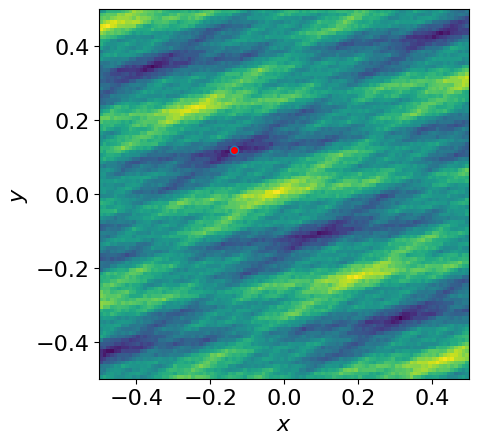

In [10]:
%matplotlib inline
fig, ax = plt.subplots()

ax.imshow(F_1_vals, extent=[*x_range, *y_range], origin="lower")
ax.plot([o_arr[0]], [o_arr[1]], linestyle="None", marker="o",
        markerfacecolor="r")

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")

plt.show(fig)

Surface plot version

In [11]:
%matplotlib inline
fig = go.Figure(data=[go.Surface(z=F_1_vals, x=x_space, y=y_space, 
                                  colorscale="Viridis")])

fig.update_traces(contours_z=dict(show=True, usecolormap=True,
                                  highlightcolor="limegreen", project_z=True))

r = 1.5
camera = {"eye": {"x": r, "y": r, "z": r}}
fig.update_layout(autosize=False, width=500, height=400, 
                  scene={"xaxis_title": "x",
                         "yaxis_title": "y",
                         "zaxis_title": "F11"},
                  margin={"l":5, "r":10, "b":5, "t":10},
                  scene_camera=camera,
                  legend={"x": 0.1, "y": 0.9})

fig.show()

## Prototyping initialization

In [12]:
def initialize_particles(bounds, N_particles, rng=None):
  if rng is None:
    print("please provide rng argument with np.random.default_rng()")
  return np.array([rng.uniform(*bound, N_particles) for bound in bounds]).T

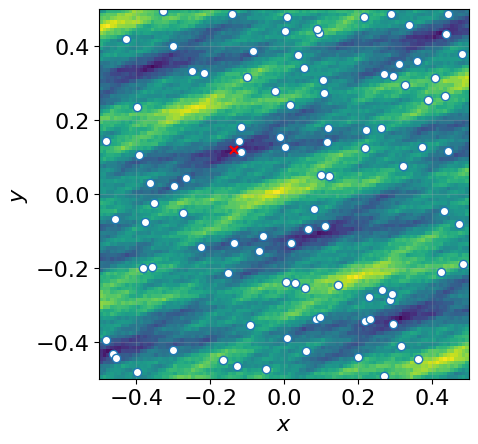

In [13]:
%matplotlib inline
D = 2
bounds = np.reshape([-0.5, 0.5]*D, (-1, D))
N_particles = 100

rng = np.random.default_rng(24_08_07)
# rng = np.random.default_rng()
# coor_particles = rng.uniform(bounds[:, 0], bounds[:, 1], (N_particles, D)) 
coor_particles = bounds[:, 0] + (bounds[:, 1] - bounds[:, 0])*rng.random((N_particles, D))
coor_particles

fig, ax = plt.subplots()

ax.imshow(F_1_vals, extent=[*x_range, *y_range], origin="lower")
ax.plot(coor_particles[:, 0], coor_particles[:, 1], linestyle="None", marker="o",
        markerfacecolor="w")
ax.plot(*o_arr[:D], linestyle="None", marker="x", markeredgewidth=1.5,
        markeredgecolor="r")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_aspect("equal")
ax.grid("on")

plt.show(fig)

## Prototyping PSO

Vectorized bound checking of `x_coor`

array([[ 0, -1],
       [ 0, -1],
       [ 1, -1],
       [ 3, -1],
       [ 3, -1],
       [ 0, -1],
       [ 0, -1],
       [ 1, -1],
       [ 3, -1],
       [ 3, -1],
       [ 0,  0],
       [ 0,  0],
       [ 1,  0],
       [ 3,  0],
       [ 3,  0],
       [ 0,  3],
       [ 0,  3],
       [ 1,  3],
       [ 3,  3],
       [ 3,  3],
       [ 0,  4],
       [ 0,  4],
       [ 1,  4],
       [ 3,  4],
       [ 3,  4],
       [ 0,  4],
       [ 0,  4],
       [ 1,  4],
       [ 3,  4],
       [ 3,  4]])

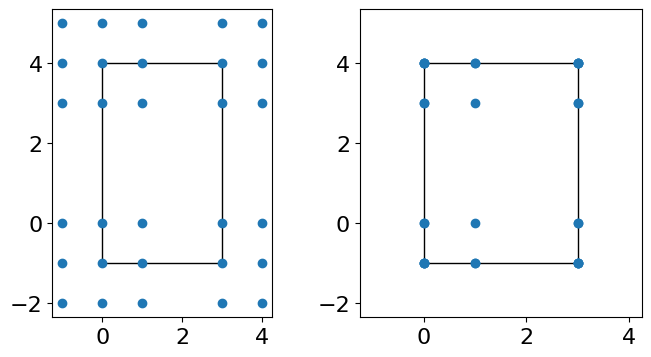

In [14]:
x_coor = np.array([
  [-1, -2], [ 0, -2], [ 1, -2], [ 3, -2], [ 4, -2],
  [-1, -1], [ 0, -1], [ 1, -1], [ 3, -1], [ 4, -1],
  [-1,  0], [ 0,  0], [ 1,  0], [ 3,  0], [ 4,  0],
  [-1,  3], [ 0,  3], [ 1,  3], [ 3,  3], [ 4,  3],
  [-1,  4], [ 0,  4], [ 1,  4], [ 3,  4], [ 4,  4],
  [-1,  5], [ 0,  5], [ 1,  5], [ 3,  5], [ 4,  5]])

N_samples = len(x_coor)

bounds = np.array([
  [ 0, 3],
  [-1, 4]])

# -- draw bounds and x_coor and x_coor after clipping
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))


rect = Rectangle(bounds[:, 0], bounds[0, 1] - bounds[0, 0], 
                  bounds[1, 1] - bounds[1, 0], facecolor="None", edgecolor="k")

axes[0].add_patch(rect)
axes[0].scatter(x_coor[:, 0], x_coor[:, 1])
axes[0].set_aspect("equal")

# -- clipping process
idx_bool = x_coor < bounds.T[0]
x_coor[idx_bool] = np.repeat(bounds.T[0][np.newaxis, :], N_samples, axis=0)[idx_bool]

idx_bool = x_coor > bounds.T[1]
x_coor[idx_bool] = np.repeat(bounds.T[1][np.newaxis, :], N_samples, axis=0)[idx_bool]

rect = Rectangle(bounds[:, 0], bounds[0, 1] - bounds[0, 0], 
                  bounds[1, 1] - bounds[1, 0], facecolor="None", edgecolor="k")
axes[1].add_patch(rect)
axes[1].scatter(x_coor[:, 0], x_coor[:, 1])

axes[1].set_xlim(axes[0].get_xlim())
axes[1].set_ylim(axes[0].get_ylim())

display(x_coor)

plt.show(fig)

Fix `v_particle`

v_fast_particles.shape (100, 2)
v_numba_support.shape (100, 2)


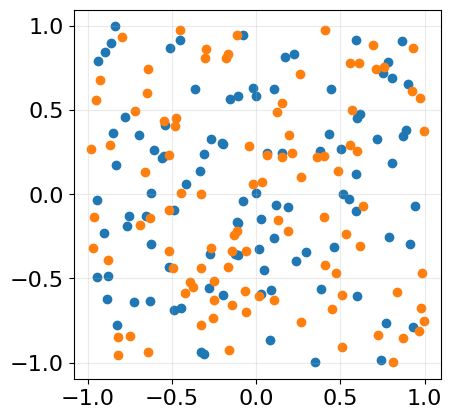

In [15]:
N_particles = 100
bounds = np.array([
  [-0.5, 0.5],
  [-0.5, 0.5]
])

fig, ax = plt.subplots()

# v_particle = np.array([rng.uniform(-(bound_high - bound_low), bound_high - bound_low, N_particles)
#           for bound_low, bound_high in bounds]).T

v_range = (bounds[:, 1] - bounds[:, 0]).flatten()
v_fast_particle = rng.uniform(-v_range, v_range, (N_particles, D))

v_numba_support = -v_range[np.newaxis, :] \
  + 2*v_range[np.newaxis, :]*rng.random((N_particles, D))

# print(f"v_particles.shape", v_particle.shape)
print(f"v_fast_particles.shape", v_fast_particle.shape)
print(f"v_numba_support.shape", v_numba_support.shape)

# ax.scatter(v_particle[:, 0], v_particle[:, 1])
ax.scatter(v_fast_particle[:, 0], v_fast_particle[:, 1])
ax.scatter(v_numba_support[:, 0], v_numba_support[:, 1])

ax.grid("on")
ax.set_aspect("equal")

plt.show(fig)

Vectorized selection `x_arr` and `x_new_arr` based on `f_x_arr` and `f_x_new_arr`

In [16]:
seed = 25_11_25
rng = np.random.default_rng(seed)
a_arr = rng.integers(-10, 10, (4, 2))
b_arr = rng.integers(-10, 10, (4, 2))

o_sol = o_arr[:D][np.newaxis, :]
M_tensor = M_D2[np.newaxis, :, :]

f_arr = obj_func_1(a_arr, o_sol, D, M_tensor)
g_arr = obj_func_1(b_arr, o_sol, D, M_tensor)

mask = f_arr < g_arr

np.where(mask, a_arr, b_arr)

array([[ -4, -10],
       [  4,   0],
       [  2,  -3],
       [ -9,   5]])

From (Zhang et al., 2015)

- `bounds` $(D \times 2)$    
  $\begin{bmatrix}x_{1,\text{min}} & x_{1,\text{max}} 
    \\ x_{2,\text{min}} & x_{2, \text{max}}
    \\ \vdots & \vdots 
    \\ x_{D,\text{min}} & x_{D, \text{max}} \end{bmatrix}$

- `coor_particles = x_arr`  $(N \times D)$       
  $\begin{bmatrix} x_{1,1} & x_{1, 2} & \ldots & x_{1, D}
    \\ x_{2,1} & x_{2,2} & \ldots & x_{2,D} 
    \\ \vdots & \vdots & & \vdots 
    \\ x_{N,1} & x_{N,2} & \ldots & x_{N,D} \end{bmatrix}$

- `f_arr` $(N \times 1)$

Computational time
- `N=400`, `iter_max=100`: 17 secs

In [17]:
D = 2
bounds = np.reshape([-0.5, 0.5]*D, (-1, 2))     # 2 in here is low and high values

# N_particles = 400
N_particles = 50

o_sol = o_arr[:D][np.newaxis, :]
# M_tensor = M_D2[np.newaxis, :, :]
M_tensor = M_D2[np.newaxis, :].copy()

# seed = 24_08_07
seed = 25_11_18
rng = np.random.default_rng(seed)
# rng = np.random.default_rng()
coor_particles = initialize_particles(bounds, N_particles, rng=rng)

iter_max = 100

obj_func_1.__dict__["mode"] = "vectorization"
g_best, data_history = psoalgo.run_pso(
  obj_func_1, coor_particles, o_sol, D, M_tensor, bounds, 
  rng=rng, iter_max=iter_max)

In [18]:
o_sol.shape

(1, 2)

In [19]:
M_tensor.shape

(1, 2, 2)

In [20]:
np.shape(data_history["x_arr"])

(102, 50, 2)

In [21]:
np.shape(data_history["g_best"])

(102, 2)

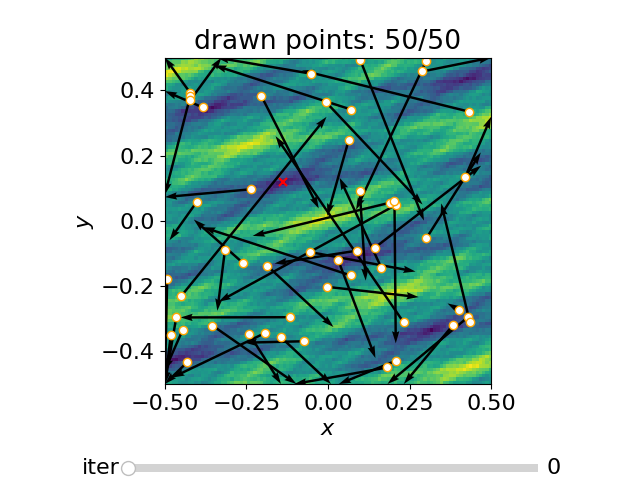

In [22]:
%matplotlib widget

fig, ax = plt.subplots()

ax.imshow(F_1_vals, extent=[*x_range, *y_range], origin="lower")
ax.plot([o_arr[0]], [o_arr[1]], linestyle="None", marker="x",
        markeredgecolor="r", markeredgewidth=1.5)
ax_pos = ax.get_position()
ax_pos.y0 = 0.2
ax.set_position(ax_pos)

# -- horizontal slider
iter = np.arange(iter_max-4)
ax_t = fig.add_axes([0.2, 0.01, 0.64, 0.03])
t_slider = Slider(ax=ax_t, label="iter", valmin=0, valmax=iter_max, valstep=1,
                  valinit=0)

skip_points = 1
for i in range(1):
  history_x_arr = data_history["x_arr"][i].copy()
  # history_v_arr = data_history["v_arr"][i].copy()
  history_v_arr = data_history["x_arr"][i+1] - history_x_arr
  history_g_best = data_history["g_best"][i].copy()
  plot_handler = ax.plot(history_x_arr[::skip_points, 0], 
                          history_x_arr[::skip_points, 1], linestyle="None", 
                          marker="o", markerfacecolor="w", markeredgecolor="orange")

  quiver_handler = ax.quiver(history_x_arr[::skip_points, 0], history_x_arr[::skip_points, 1], 
            history_v_arr[::skip_points, 0], history_v_arr[::skip_points, 1],
            units="xy", scale_units="xy", scale=1.)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title(f"drawn points: {len(coor_particles[::skip_points])}/{N_particles}")

# print(dir(quiver_handler))


# -- slider update function 
def update_slider(val):
  val = int(val)
  history_x_arr = data_history["x_arr"][val].copy()
  # history_v_arr = data_history["v_arr"][val+1].copy()
  history_v_arr = data_history["x_arr"][val+1] - data_history["x_arr"][val]
  plot_handler[0].set_xdata(history_x_arr[::skip_points, 0])
  plot_handler[0].set_ydata(history_x_arr[::skip_points, 1])
  quiver_handler.set_offsets(history_x_arr[::skip_points])
  quiver_handler.set_UVC(history_v_arr[::skip_points, 0], history_v_arr[::skip_points, 1])
  fig.canvas.draw_idle()

t_slider.on_changed(update_slider)

plt.show(fig)

Draw selected `iter`

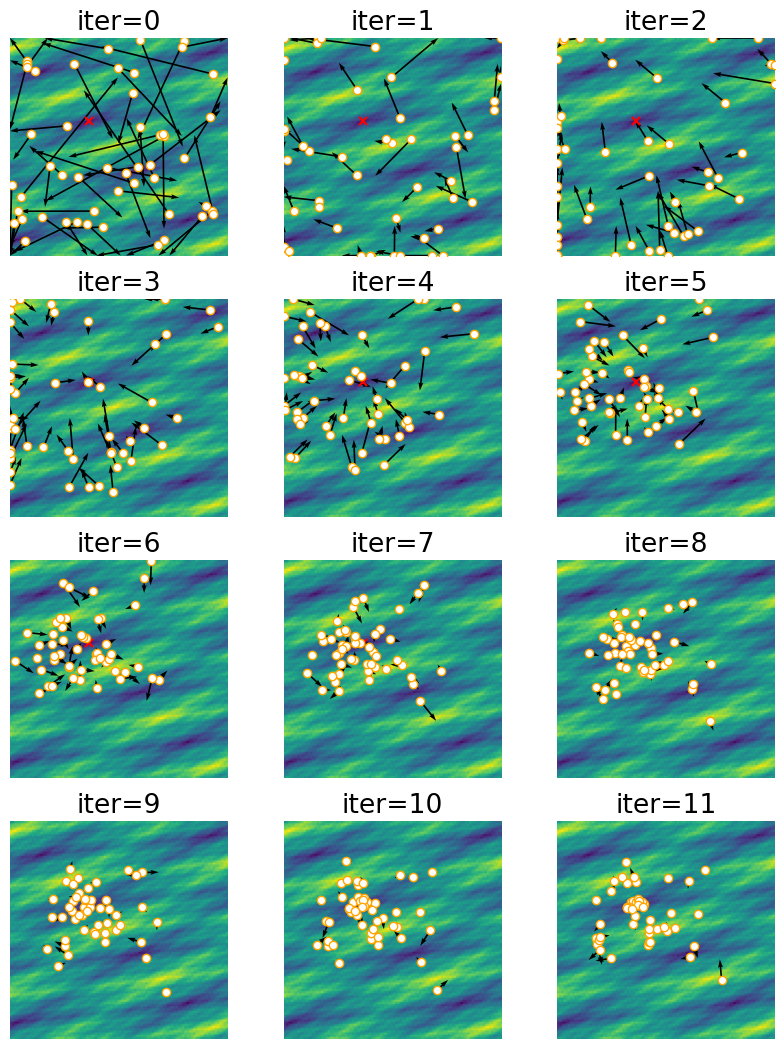

In [45]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10, 13), sharex=True, sharey=True)

selected_iter = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
skip_points = 1
for idx, ax in enumerate(axes.flatten()):
  ax.imshow(F_1_vals, extent=[*x_range, *y_range], origin="lower")
  ax.plot([o_arr[0]], [o_arr[1]], linestyle="None", marker="x",
          markeredgecolor="r", markeredgewidth=1.5)

  history_x_arr = data_history["x_arr"][idx].copy()
  history_v_arr = data_history["x_arr"][idx+1] - history_x_arr
  ax.plot(history_x_arr[::skip_points, 0], history_x_arr[::skip_points, 1], 
            linestyle="None", marker="o", markerfacecolor="w", markeredgecolor="orange")
  ax.quiver(history_x_arr[::skip_points, 0], history_x_arr[::skip_points, 1], 
            history_v_arr[::skip_points, 0], history_v_arr[::skip_points, 1],
            units="xy", scale_units="xy", scale=1.)
  ax.axis("off")

  ax.set_title(f"iter={selected_iter[idx]}")

plt.show(fig)

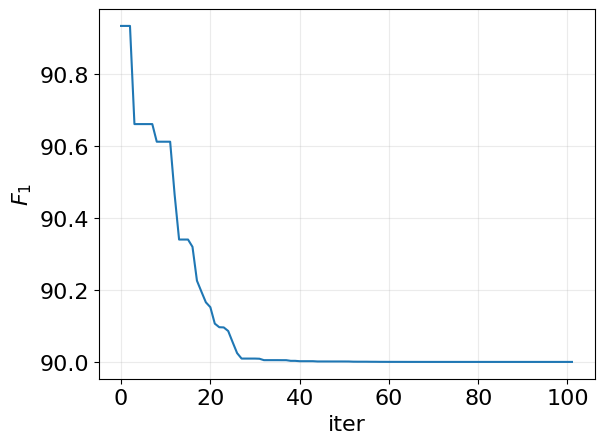

In [24]:
%matplotlib inline

fig, ax = plt.subplots()

history_g_best = data_history["g_best"]
ax.plot(obj_func_1(history_g_best, o_sol, D, M_tensor))

ax.set_ylabel("$F_1$")
ax.set_xlabel("iter")
ax.grid("on")

plt.show(fig)

In [25]:
obj_func_1(coor_particles, o_sol, D, M_tensor)

array([[93.75563424],
       [91.42070111],
       [94.39618855],
       [93.6704586 ],
       [93.66681566],
       [93.88639996],
       [94.99446067],
       [94.27726761],
       [92.00722528],
       [90.93383598],
       [94.2277655 ],
       [92.85834063],
       [93.53662729],
       [92.87305145],
       [93.78461587],
       [93.83460288],
       [92.60550985],
       [94.23927848],
       [93.55993655],
       [92.17712679],
       [95.72938408],
       [92.9890535 ],
       [94.1867976 ],
       [91.42944774],
       [94.68347808],
       [92.02575759],
       [93.55133269],
       [93.93151712],
       [93.68333961],
       [94.02203894],
       [93.20361725],
       [92.66167838],
       [95.29550843],
       [94.60593097],
       [93.72930595],
       [93.41252067],
       [92.27054037],
       [94.82770434],
       [93.92603136],
       [93.61182327],
       [93.79519159],
       [94.67498784],
       [93.13767702],
       [94.82110469],
       [93.43933585],
       [92

Test for $N$ runs

In [39]:
D = 2
bounds = np.reshape([-0.5, 0.5]*D, (-1, 2))     # 2 in here is low and high values

N_particles = 50
# N_particles = 400
# N_particles = 1000
# N_particles = 5000

o_sol = o_arr[:D][np.newaxis, :]
# M_tensor = M_D2[np.newaxis, :, :]
M_tensor = M_D2.copy()

seed = 25_11_04
rng = np.random.default_rng(seed)
# rng = np.random.default_rng()
# coor_particles = initialize_particles(bounds, N_particles, rng=rng)
# coor_particles = bounds[:, 0] + (bounds[:, 1] - bounds[:, 0])*rng.random((N_particles, D))

iter_max = 100

# runs_history = {
#   "best_solution": [], 
#   "best_fitness": [], 
#   "data_history": []
# }

runs_history = {
  "best_solution": [], 
  "best_fitness": [], 
  "history_p_arr": [],
  "history_f_p_arr": []
}

# num_of_runs = 10      # 3 secs / 400 particles
# num_of_runs = 100     # 22 secs / 400 particles
                        # 6 secs / 50 particles

num_of_runs = 1000     # 48 secs / 50 particles
                       # 2 mins 17 secs / 400 particles
                       # 4 mins 59 secs / 1000 particles
                       # 23 mins 19 secs / 5000 particles

w = 0.5
phi_p = 0.3
phi_g = 0.3
params = [w, phi_p, phi_g]

for i in range(num_of_runs):
  print(f"run: {i}")

  history_p_arr, history_f_p_arr, history_g_best, history_f_g_best \
    = psoalgo_numba.run_pso_numba(
        obj_func_1_numba, N_particles, o_sol, D, M_tensor, bounds, params, 
        rng, iter_max=iter_max)

  runs_history["best_solution"].append(history_g_best)
  runs_history["best_fitness"].append(history_f_g_best)
  runs_history["history_p_arr"].append(np.array(history_p_arr))
  runs_history["history_f_p_arr"].append(history_f_p_arr)


run: 0
run: 1
run: 2
run: 3
run: 4
run: 5
run: 6
run: 7
run: 8
run: 9
run: 10
run: 11
run: 12
run: 13
run: 14
run: 15
run: 16
run: 17
run: 18
run: 19
run: 20
run: 21
run: 22
run: 23
run: 24
run: 25
run: 26
run: 27
run: 28
run: 29
run: 30
run: 31
run: 32
run: 33
run: 34
run: 35
run: 36
run: 37
run: 38
run: 39
run: 40
run: 41
run: 42
run: 43
run: 44
run: 45
run: 46
run: 47
run: 48
run: 49
run: 50
run: 51
run: 52
run: 53
run: 54
run: 55
run: 56
run: 57
run: 58
run: 59
run: 60
run: 61
run: 62
run: 63
run: 64
run: 65
run: 66
run: 67
run: 68
run: 69
run: 70
run: 71
run: 72
run: 73
run: 74
run: 75
run: 76
run: 77
run: 78
run: 79
run: 80
run: 81
run: 82
run: 83
run: 84
run: 85
run: 86
run: 87
run: 88
run: 89
run: 90
run: 91
run: 92
run: 93
run: 94
run: 95
run: 96
run: 97
run: 98
run: 99
run: 100
run: 101
run: 102
run: 103
run: 104
run: 105
run: 106
run: 107
run: 108
run: 109
run: 110
run: 111
run: 112
run: 113
run: 114
run: 115
run: 116
run: 117
run: 118
run: 119
run: 120
run: 121
run: 122
run

In [40]:
print(np.array(runs_history["best_solution"]).shape)
print(np.array(runs_history["best_fitness"]).shape)
print(np.array(runs_history["history_p_arr"]).shape)
print(np.array(runs_history["history_f_p_arr"]).shape)

# for p_arr in runs_history["history_p_arr"]:
#   print([p.shape for p in p_arr])
# for f_p_arr in runs_history["history_f_p_arr"]:
#   print([f_p.shape for f_p in f_p_arr])

(1000, 102, 1, 2)
(1000, 102, 1, 1)
(1000, 102, 50, 2)
(1000, 102, 50, 1)


In [41]:
# For num_of_runs = 1000:  
# - xx secs / 400 particles
# - x secs / 50 particles

is_saved = True
# filename = f"./results/PSO-vectorized-numOfRuns-{num_of_runs}-Nparticles-{N_particles}-iterMax-{iter_max}.npz"
filename = f"./results/PSO-vectorized-numba-numOfRuns-{num_of_runs}-Nparticles-{N_particles}-iterMax-{iter_max}.npz"

if is_saved:
  np.savez(filename, best_solution=np.array(runs_history["best_solution"]), 
            best_fitness=np.array(runs_history["best_fitness"]), 
            history_p_arr=np.array(runs_history["history_p_arr"]),
            history_f_p_arr=np.array(runs_history["history_f_p_arr"]))


Reload data

In [13]:
N_particles = 50
iter_max = 100
num_of_runs = 1000

filename = f"./results/PSO-vectorized-numba-numOfRuns-{num_of_runs}-Nparticles-{N_particles}-iterMax-{iter_max}.npz"
runs_history = np.load(filename, allow_pickle=True)

History plots for many runs (vectorized)

In [42]:
# fig, ax = plt.subplots()

# temp_sum = np.zeros(iter_max)
# for data_history in runs_history["data_history"]:
#   history_g_best = np.array(data_history["g_best"])
#   # g_best_F1 = obj_func_1(history_g_best, o_sol, D, M_tensor)
#   g_best_F1 = np.array(data_history["f_g_best"])
#   ax.plot(g_best_F1.flatten()[1:], color="tab:blue", alpha=0.1, 
#           linestyle="None", marker=".")
#   # print(f"g_best_F1", g_best_F1.shape)
#   temp_sum += g_best_F1.flatten()[2:]

# runs_mean = temp_sum/num_of_runs

# runs_std = np.zeros(iter_max)
# temp_var = np.zeros(iter_max)
# for data_history in runs_history["data_history"]:
#   history_g_best = np.array(data_history["g_best"])
#   # g_best_F1 = obj_func_1(history_g_best, o_sol, D, M_tensor)
#   g_best_F1 = np.array(data_history["f_g_best"])
#   temp_var += (g_best_F1.flatten()[2:] - runs_mean)**2

# runs_std = np.sqrt(temp_var/num_of_runs)
# ax.plot(runs_mean, color="tab:red", label="mean")
# ax.plot(runs_mean + runs_std, color="tab:orange", label="std", linestyle="--")

# lower_bound = runs_mean - runs_std
# lower_bound[lower_bound < 90] = 90
# ax.plot(lower_bound, color="tab:orange", label=None, linestyle="--")

# ax.set_ylabel("$F_1$")
# ax.set_xlabel("iter")
# ax.set_ylim([89.9, 92])

# ax.set_title(f"num. of runs: {num_of_runs:,}")
# ax.grid("on")
# ax.legend(loc="best")


# plt.show(fig)

History plots for many runs (vectorized + numba)

In [14]:
np.shape(runs_history["best_fitness"])

(1000, 102, 1, 1)

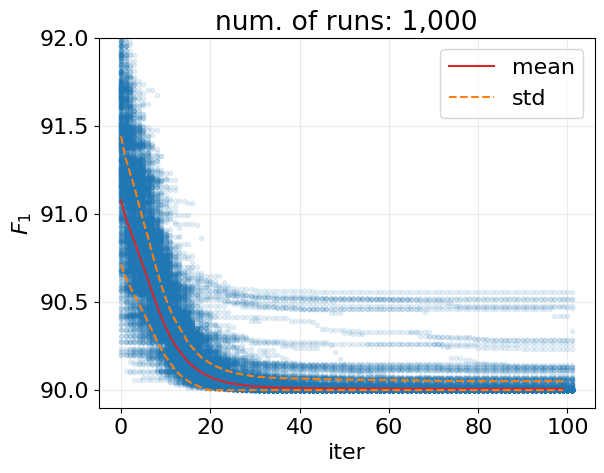

In [15]:
fig, ax = plt.subplots()

temp_sum = np.zeros(iter_max)
for history_f_g_best in runs_history["best_fitness"]:
  # g_best_F1 = obj_func_1(history_g_best, o_sol, D, M_tensor)
  ax.plot(history_f_g_best[:, 0, 0], color="tab:blue", alpha=0.1, 
          linestyle="None", marker=".")
  # print(f"g_best_F1", g_best_F1.shape)
  temp_sum += np.array(history_f_g_best).flatten()[2:]

runs_mean = temp_sum/num_of_runs

runs_std = np.zeros(iter_max)
temp_var = np.zeros(iter_max)
for history_f_g_best in runs_history["best_fitness"]:
  # g_best_F1 = obj_func_1(history_g_best, o_sol, D, M_tensor)
  temp_var += (np.array(history_f_g_best).flatten()[2:] - runs_mean)**2

runs_std = np.sqrt(temp_var/num_of_runs)
ax.plot(runs_mean, color="tab:red", label="mean")
ax.plot(runs_mean + runs_std, color="tab:orange", label="std", linestyle="--")

lower_bound = runs_mean - runs_std
lower_bound[lower_bound < 90] = 90
ax.plot(lower_bound, color="tab:orange", label=None, linestyle="--")

ax.set_ylabel("$F_1$")
ax.set_xlabel("iter")
ax.set_ylim([89.9, 92])

ax.set_title(f"num. of runs: {num_of_runs:,}")
ax.grid("on")
ax.legend(loc="best")


plt.show(fig)

In [45]:
# fig, ax = plt.subplots()

# runs_best_fitness = np.array([best_fitness[-1] for best_fitness in runs_history["best_fitness"]])
# ax.plot(runs_best_fitness.flatten(), label=f"best_fitness={np.min(runs_best_fitness):.2f}")

# # -- average
# mean_runs_best_fitness = np.mean(runs_best_fitness)
# ax.axhline(mean_runs_best_fitness, color="tab:orange", 
#             label=f"mean={mean_runs_best_fitness:.2f}")

# # -- ground truth
# ax.axhline(F_1_min, color="tab:red")

# ax.grid("on")
# ax.set_xlabel("#-th run")
# ax.set_ylabel("fitness")
# ax.set_title(f"N_particles={N_particles}; iter_max={iter_max}")
# ax.legend(loc="best")

# plt.show(fig)

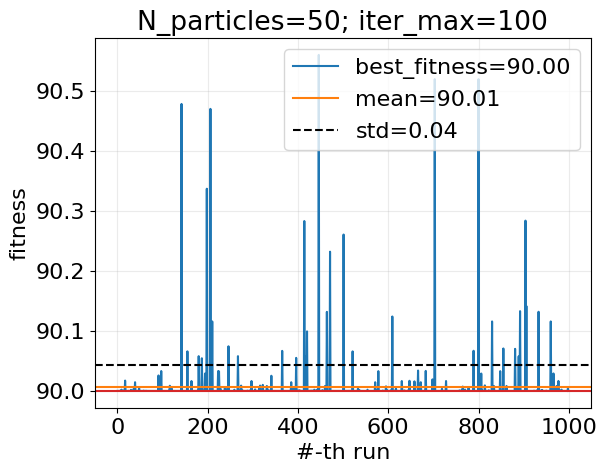

In [17]:
fig, ax = plt.subplots()

runs_best_fitness = np.array([best_fitness[-1] for best_fitness in runs_history["best_fitness"]])
ax.plot(runs_best_fitness.flatten(), label=f"best_fitness={np.min(runs_best_fitness):.2f}")

# -- average and its stddev
mean_runs_best_fitness = np.mean(runs_best_fitness)
ax.axhline(mean_runs_best_fitness, color="tab:orange", 
            label=f"mean={mean_runs_best_fitness:.2f}")
stddev_runs_best_fitness = np.std(runs_best_fitness)
ax.axhline(F_1_min + stddev_runs_best_fitness, color="k",
            linestyle="--", label=f"std={stddev_runs_best_fitness:.2f}")

# -- ground truth
ax.axhline(F_1_min, color="tab:red")

ax.grid("on")
ax.set_xlabel("#-th run")
ax.set_ylabel("fitness")
ax.set_title(f"N_particles={N_particles}; iter_max={iter_max}")
ax.legend(loc="best")

plt.show(fig)

Comparison to `pso-prototype.ipynb`

In [47]:
filename = "./results/PSO-with-loop-numba-numOfRuns-1000-Nparticles-50-iterMax-100.npz"
pso_with_loop_data_history = np.load(filename, allow_pickle=True)

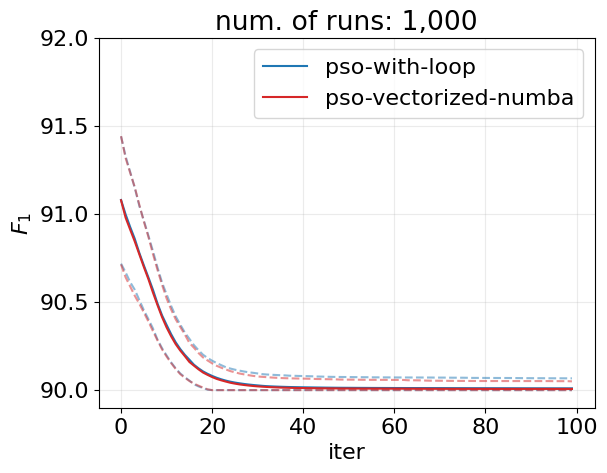

In [48]:
fig, ax = plt.subplots()

# -- PSO with loops
temp_sum = np.zeros(iter_max) 
temp_sum_of_sq = np.zeros(iter_max)
for f_g_best in pso_with_loop_data_history["best_fitness"]:
  temp_sum += np.array(f_g_best).flatten()[2:]
  temp_sum_of_sq += np.array(f_g_best).flatten()[2:]**2

runs_mean = temp_sum/num_of_runs
runs_std = np.sqrt(temp_sum_of_sq/num_of_runs - runs_mean**2)
ax.plot(runs_mean, color="tab:blue", label="pso-with-loop")
ax.plot(runs_mean + runs_std, color="tab:blue", label=None, 
        linestyle="--", alpha=0.5)
lower_bound = runs_mean - runs_std
lower_bound[lower_bound < 90] = 90
ax.plot(lower_bound, color="tab:blue", label=None, 
        linestyle="--", alpha=0.5)

# -- PSO vectorized
temp_sum = np.zeros(iter_max) 
temp_sum_of_sq = np.zeros(iter_max)
# for data_history in runs_history["data_history"]:
#   history_g_best = np.array(data_history["g_best"])
#   g_best_F1 = obj_func_1(history_g_best, o_sol, D, M_tensor)
#   temp_sum += g_best_F1.flatten()[2:]
#   temp_sum_of_sq += g_best_F1.flatten()[2:]**2
for f_g_best in runs_history["best_fitness"]:
  temp_sum += np.array(f_g_best).flatten()[2:]
  temp_sum_of_sq += np.array(f_g_best).flatten()[2:]**2

runs_mean = temp_sum/num_of_runs
runs_std = np.sqrt(temp_sum_of_sq/num_of_runs - runs_mean**2)
ax.plot(runs_mean, color="tab:red", label="pso-vectorized-numba")
ax.plot(runs_mean + runs_std, color="tab:red", label=None, 
        linestyle="--", alpha=0.5)
lower_bound = runs_mean - runs_std
lower_bound[lower_bound < 90] = 90
ax.plot(lower_bound, color="tab:red", label=None, 
        linestyle="--", alpha=0.5)

ax.set_ylabel("$F_1$")
ax.set_xlabel("iter")
ax.set_ylim([89.9, 92])
ax.set_title(f"num. of runs: {num_of_runs:,}")
ax.grid("on")
ax.legend(loc="best")

plt.show(fig)